In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score


# displays all the column
pd.set_option('display.max_columns', None)
# float format set at 5 decimal places
pd.options.display.float_format = '{:,.5f}'.format
# separator for display format
spacer = 'x' * 100

In [29]:
employee = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Employee Salary Analysis/Datasets/employee_attrition_hr_2026.csv')

employee.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,14.10000,7.30000,15.90000,1.50000,3,Remote,5,2.40000,6,17,9.40000,1.00000,9.70000,7.70000,3,8.30000,True,4.80000,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,7.90000,3.00000,4.00000,2.50000,3,Onsite,7,4.10000,5,21,4.20000,1.90000,5.40000,7.80000,3,8.00000,True,2.90000,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,12.80000,3.00000,4.00000,1.30000,3,Hybrid,28,3.30000,7,22,7.50000,5.30000,6.50000,7.00000,4,9.50000,True,7.20000,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,12.80000,9.20000,12.50000,0.50000,0,Hybrid,19,12.00000,21,21,8.70000,4.30000,7.30000,3.50000,4,7.90000,False,5.20000,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,10.60000,4.90000,10.50000,0.20000,0,Hybrid,36,4.90000,20,20,7.50000,2.30000,7.00000,7.20000,4,8.50000,False,6.40000,No


* Dataset obtained from: https://www.kaggle.com/datasets/uditjain13/employee-attrition-and-hr-analytics-2026

* Dataset is synthetically generated using numpy.

* Each row represents an employee.

**Columns**:
  * employee_id: identifier for the employee.
  * age: age of the employee.
  * gender: gender of the employee.
  * marital_status: marital_status of the employee.
  * education_level: the highest education the employee had.
  * department: work department where the employee belongs.
  * job_role: the position of the employee.
  * job_level: job rank of the employee which defines his/hers responsibilities and expertise.
  * monthly_income: monthly income of the employee.
  * stock_option_level: indicates the potential company ownership of the employee based on his responsibilities and expertise.
  * salary_hike_pct: percentage of potential salary increase of the employee.
  * years_at_company: employee's tenure in the company.
  * total_working_years: employee's experience overall.
  * years_since_promotion: how many years since the last employee's promotion?
  * num_prior_companies: number of employers the employee had.
  * work_mode: the work arrangement of the employee.
  * commute_minutes: the time it took for an employee to reach his workplace by commuting.
  * overtime_hours_per_week: average total hours of overtime the employee had per week.
  * business_travel_days_per_year: number of business travel days the employee had in a year.
  * training_hours: the hours it took for an employee to finish training.
  * manager_support_score: score given by the employee to his manager/supervisors performance.
  * burnout_score: score given by the employee as how burned out he/she is.
  * engagement_score: employee's score on how they feel about their jobs or the company, usually evaluated by the HR.
  * work_life_balance_score: employee's score on how they divide their time in work and their own lives.
  * performance_rating: employee's final work performance as evaluated by their Manager/ HR.
  * last_review_score: raw score from the latest performance evaluation.
  * uses_ai_tools_at_work: determines if the employee uses ai at work.
  * perceived_ai_job_risk: employee's score on how they feel about AI replacing their jobs.
  * attrition: if employee leaves or not.


Assuming this dataset represents a company's HR records and metrics for employees it is possible to:
  * predict the monthly income of an employee
    * review certain employees if they are being underpaid.
    * analyze factors affecting the income of an employee.
  * predict employee performance
    * analyze factors affecting employee performance.
    * identify high potential employees for promotion.
    * identify low performing employees for coaching.
    * assign important tasks to high potential employees.
  * Predict overtime hours
    * redistribute work or hire new employees.
    * to reduce burnouts to employees.

# Data Profiling

In [30]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

In [31]:
# no extreme values are observed in the employee metrics.
employee.describe()

,employee_id,age,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,perceived_ai_job_risk
count,"5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000","5,000.00000"
mean,"3,500.50000",37.11980,2.92520,"6,990.71980",1.08980,11.51820,6.72462,11.69926,1.97190,1.80520,31.16020,6.82822,10.81900,22.59880,6.61350,4.03336,6.50798,6.13036,3.61580,8.33092,4.85672
std,"1,443.52000",8.23416,1.20162,"2,701.89936",0.93654,3.40802,3.50022,4.99587,1.62824,1.34567,19.43507,4.47052,8.09223,11.00602,1.83660,1.54004,1.49768,1.28829,0.66142,1.14913,1.83243
min,"1,001.00000",21.00000,1.00000,"1,500.00000",0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,1.00000,1.00000,2.00000,2.80000,1.00000
25%,"2,250.75000",31.00000,2.00000,"4,971.00000",0.00000,9.30000,4.27500,8.30000,0.80000,1.00000,14.00000,3.60000,5.00000,15.00000,5.40000,2.90000,5.50000,5.30000,3.00000,7.50000,3.60000
50%,"3,500.50000",37.00000,3.00000,"6,569.00000",1.00000,11.60000,6.80000,11.90000,1.60000,2.00000,33.00000,5.90000,7.00000,22.00000,6.70000,4.00000,6.50000,6.20000,4.00000,8.40000,4.90000
75%,"4,750.25000",43.00000,4.00000,"8,604.25000",2.00000,13.80000,9.20000,15.10000,2.80000,3.00000,46.00000,9.00000,18.00000,30.00000,7.90000,5.00000,7.60000,7.00000,4.00000,9.20000,6.10000
max,"6,000.00000",64.00000,5.00000,"21,609.00000",3.00000,22.60000,18.10000,30.40000,11.10000,8.00000,92.00000,34.90000,38.00000,67.00000,10.00000,10.00000,10.00000,9.90000,5.00000,10.00000,10.00000


In [32]:
employee.describe(include='object')

,gender,marital_status,education_level,department,job_role,work_mode,attrition
count,5000,5000,5000,5000,5000,5000,5000
unique,4,3,4,8,25,3,2
top,Male,Married,Bachelors,Engineering,Engineering Manager,Hybrid,No
freq,2492,2387,2562,1336,346,2237,4105


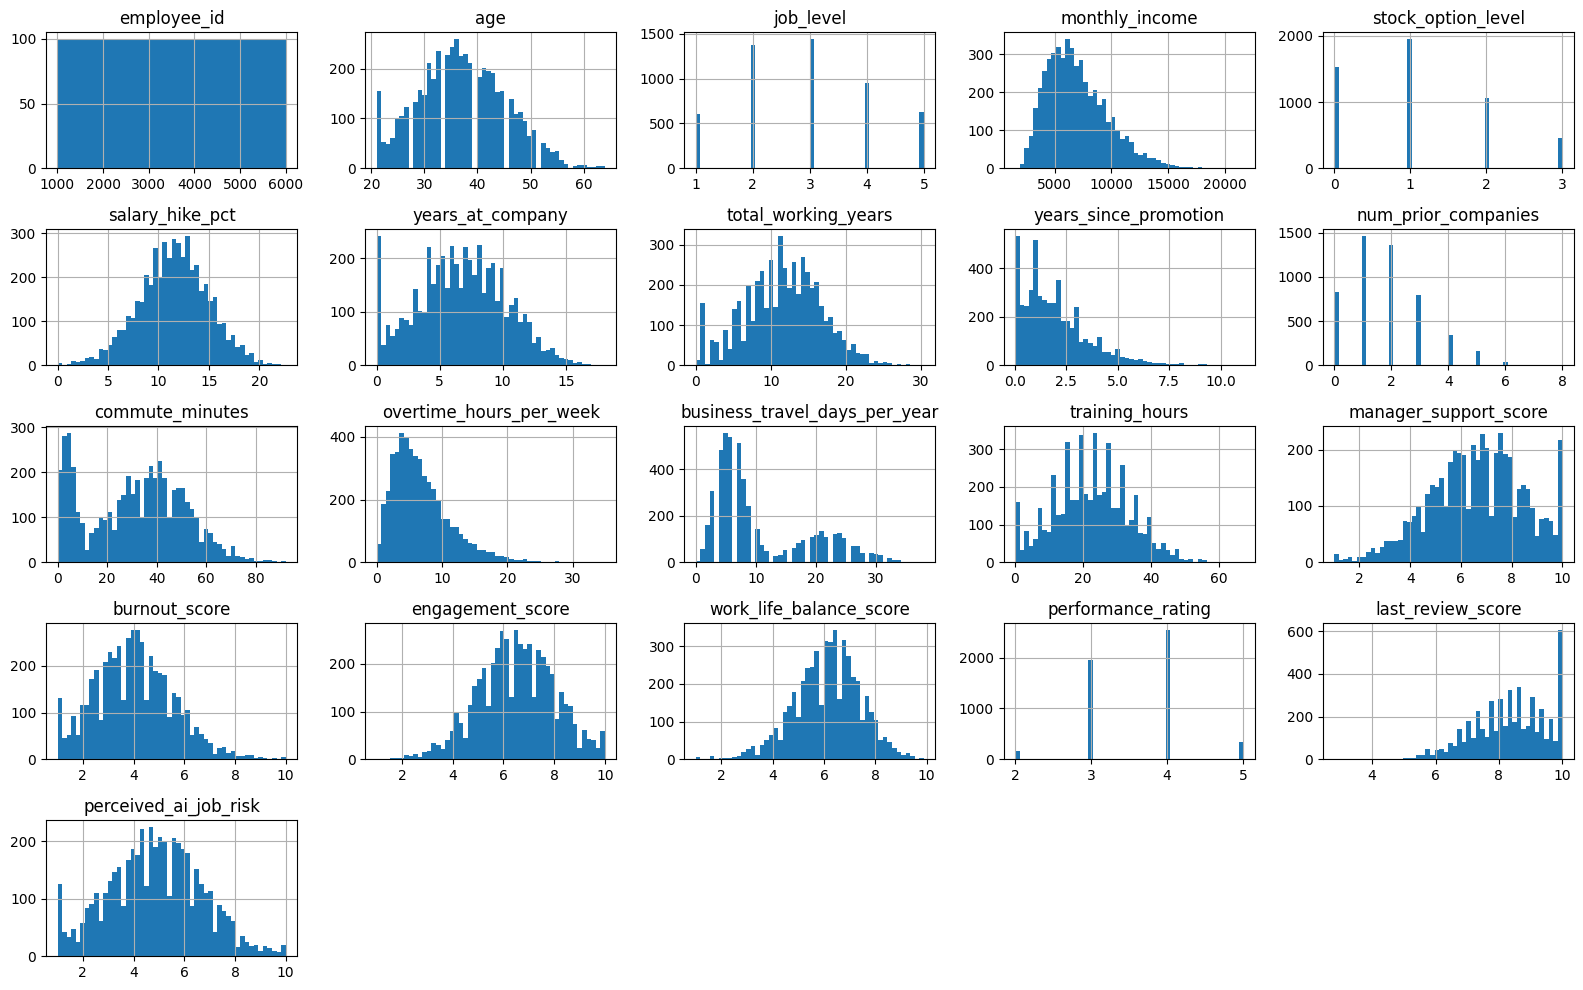

In [33]:
# there are certain skewed metrics but most of it are normally distributed.
employee.hist(figsize=(16,10), bins=50)
plt.tight_layout()
plt.show()

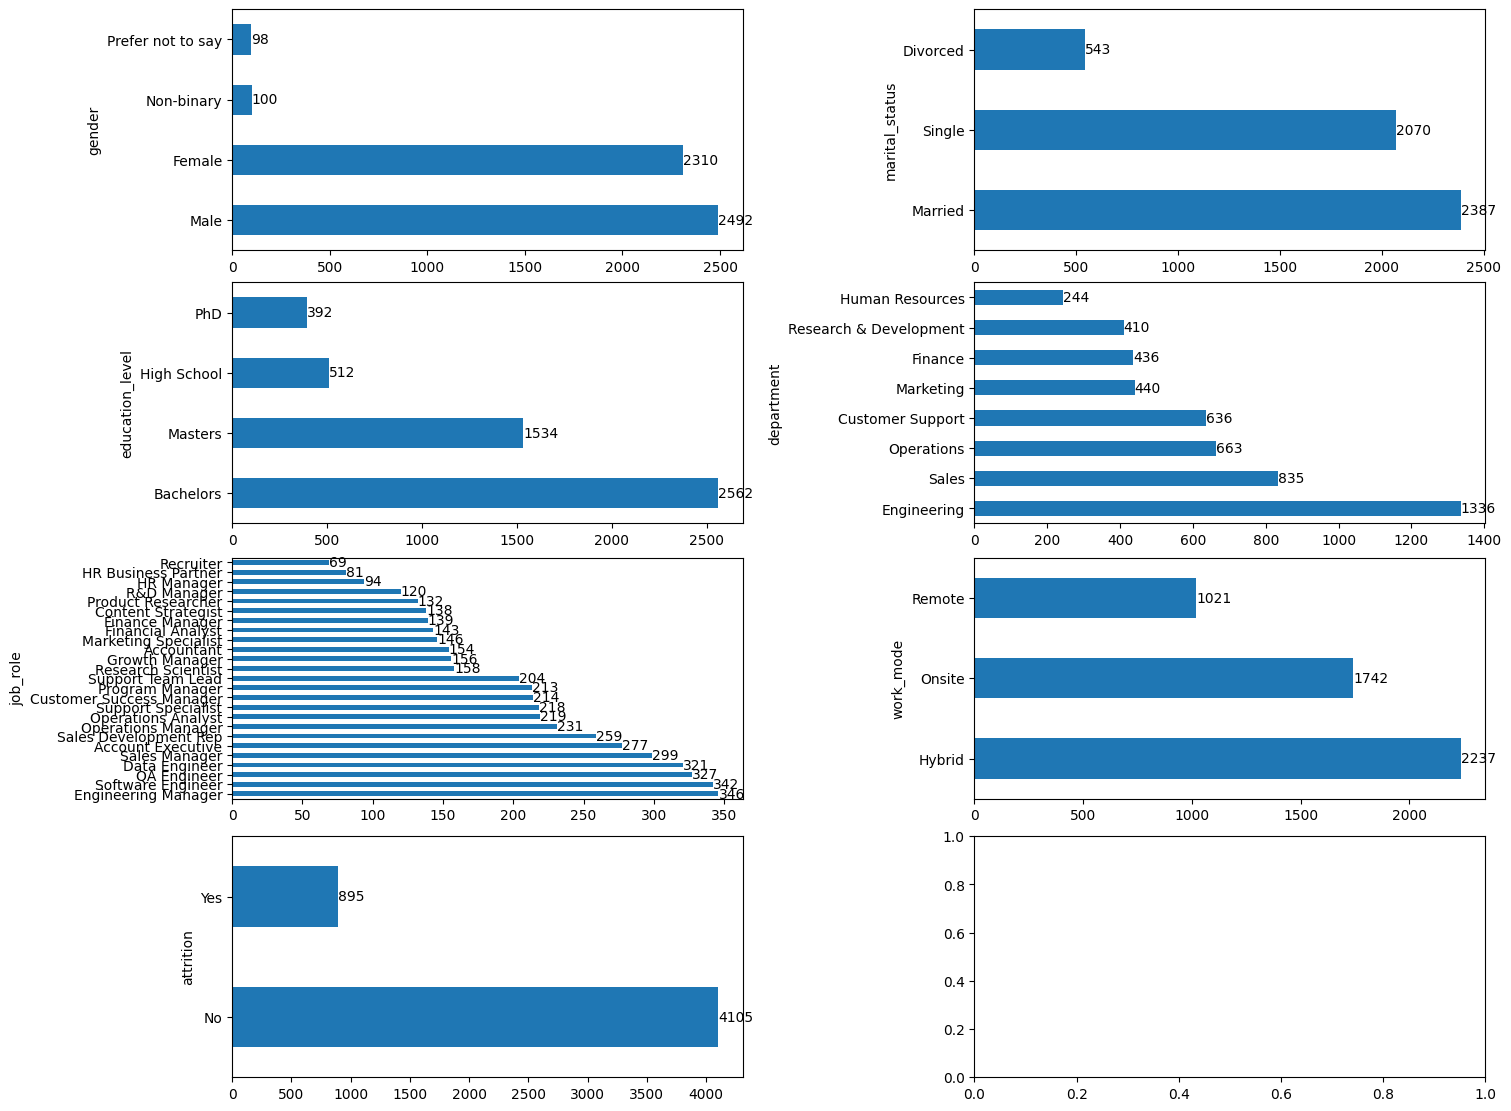

In [34]:
# Ordinal Encoder can be used for education_level since it is interpreted in order, One hot encoder for other categorical columns.
# There are no extreme values for categorical columns.
cols = employee.select_dtypes('object').columns
fig, ax = plt.subplots(nrows=4, ncols=2,figsize=(15,11),layout='constrained')
ax = ax.flatten()

for i, col in enumerate(cols):
  employee[col].value_counts().plot(kind='barh', ax=ax[i])
  ax[i].bar_label(ax[i].containers[0])
plt.show()


# Predicting Monthly Income

## Splitting Data

In [35]:
# Splitting Data
# Use job_level as basis for splitting the data.
# job_level is an important feature that can dictate an employee monthly income, it represents his current authority and responsibilities.

X = employee.drop(columns=['monthly_income','employee_id'])
y = employee['monthly_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=employee['job_level'], random_state=42)

# check proportions for both training and testing sets
pd.merge(
    X_train['job_level'].value_counts(normalize=True).reset_index(name='training_proportion'),
    X_test['job_level'].value_counts(normalize=True).reset_index(name='testing_proportion')
).set_index('job_level')

,training_proportion,testing_proportion
job_level,,
3,0.28875,0.28900
2,0.27575,0.27500
4,0.18950,0.19000
5,0.12575,0.12600
1,0.12025,0.12000


## Correlation

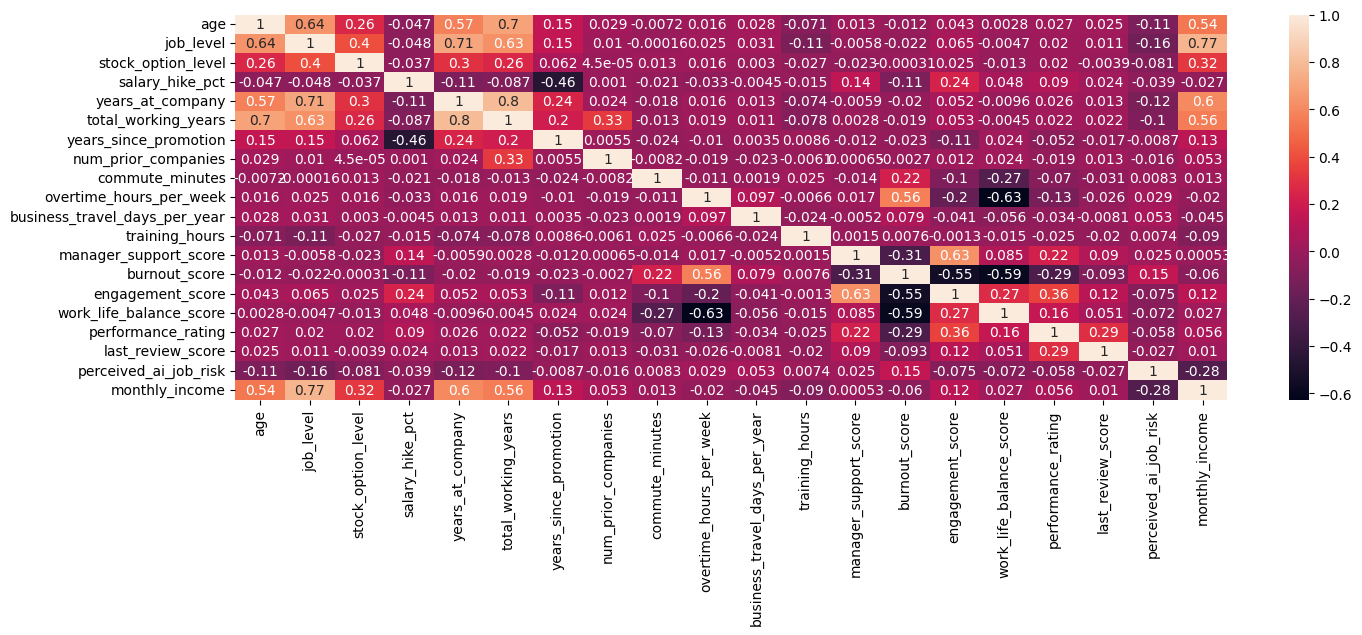

In [36]:
# Correlation
# Strongest correlation for monthly_income are job_level, years_at_company, total_working_years, age, and stock_option_level.
# Multicollinearity is not present.
train = X_train.join(y_train)
plt.figure(figsize=(16,5))
sns.heatmap(train.select_dtypes(np.number).corr(), annot=True)
plt.show()

## Modelling

In [37]:
# define modelling functions.

education_order = ['High School','Bachelors','Masters','PhD']

# pipeline
def create_pipeline( model, skewed_cols, unskewed_cols, cat_cols, order_cols):

    # Generates a custom pipeline dynamically based on the columns provided.
    preprocessor = ColumnTransformer(
        transformers=[
            ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), skewed_cols),
            ("passthrough_features", "passthrough", unskewed_cols),
            ("onehot_encode", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
            ('ordinal_encode', OrdinalEncoder(categories=[education_order]), order_cols)
        ],
        remainder='drop'
    )

    return Pipeline([
        ("prep", preprocessor),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
# metrics
def show_metrics(actual, pred):
    final_rmse = np.sqrt(mean_squared_error(actual, pred))
    final_mae = mean_absolute_error(actual, pred)
    final_r2 = r2_score(actual, pred)
    final_mape = mean_absolute_percentage_error(actual, pred)
    final_20 = percentage_of_error_within_threshold(actual, pred, 20)

    print("RMSE: ",final_rmse)
    print("MAE: ",final_mae)
    print("R2: ", final_r2)
    print("MAPE: ", final_mape)
    print("Percentage of Predicted Values with 20% error and below: ",final_20)

# function for computing percentage of predicted values with (n%) error
def percentage_of_error_within_threshold(actual, pred, percentage):
    abs_resid = np.absolute(actual - pred)
    percentage_error = (abs_resid / actual) * 100
    mask = percentage_error <= percentage
    return percentage_error[mask].count() / actual.shape[0] * 100

In [45]:
# evaluating different models to see which performs better.
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "SGD Regressor": SGDRegressor(penalty=None, random_state=42),
    "Support Vector Regressor": SVR(C=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Ensure target is a Pandas Series so .count() works in percentage_of_error_within_threshold
y_test_series = pd.Series(y_test) if isinstance(y_test, np.ndarray) else y_test


cv_summary = []
for name, model_instance in models.items():
    print(f"\n==================== {name} ====================")


    pipeline = create_pipeline(
        model=model_instance,
        skewed_cols=skewed_cols,
        unskewed_cols=unskewed_cols,
        cat_cols=cat_cols,
        order_cols=order_cols
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    show_metrics(y_test_series, y_pred)

    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=5,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
        n_jobs=-1
    )

    cv_summary.append({
        "Model": name,
        "CV Mean RMSE": -cv_results['test_rmse'].mean(),
        "CV RMSE Std": cv_results['test_rmse'].std(),
        "CV Mean R2": cv_results['test_r2'].mean()
    })

cv_df = pd.DataFrame(cv_summary).sort_values(by="CV Mean RMSE")
print(cv_df.to_string(index=False))


==================== Linear Regression ====================
RMSE:  1214.5761601085387
MAE:  926.9671820861822
R2:  0.8036352906339046
MAPE:  0.1371031187230176
Percentage of Predicted Values with 20% error and below:  75.5

==================== Ridge Regression ====================
RMSE:  1214.605077509144
MAE:  926.9456469704213
R2:  0.8036259401711687
MAPE:  0.13709385806244356
Percentage of Predicted Values with 20% error and below:  75.5

==================== Lasso Regression ====================
RMSE:  1214.517794422791
MAE:  926.902426443693
R2:  0.803654162543169
MAPE:  0.13709049787239533
Percentage of Predicted Values with 20% error and below:  75.5

==================== SGD Regressor ====================
RMSE:  1222.5203049733902
MAE:  939.4114416108564
R2:  0.8010581755727344
MAPE:  0.13974242993168484
Percentage of Predicted Values with 20% error and below:  75.3

==================== Support Vector Regressor ====================
RMSE:  2749.7247626743724
MAE:  2122.663789

In [44]:
# Gradient Boosting Regressor performed the best in both raw prediction and cross-validation.
# Gradient Boosting Regressor is similar to random forest regressor where each decision tree evaluates,
# the difference is gradient boosting decision trees evaluates the prior decision trees residual errors.
# it continues to correct the error of the first decision tree until the prediction is spot on.

# Based on error metrics, the Gradient Boosting Regressor Model predicted the monthly income of an employee on average higher or lower than 912 dollars.
# The RMSE is 1193 dollars which is close to the value of MAE indicating that the target variable is not heavily skewed.
# R2 score scored higher with 0.81 explaining that 81% of the targets variability is explained by the features.
# MAPE scored lower at 13% which shows that the magnitude of predicted errors is low.

gradient_pipeline = create_pipeline(
        model= GradientBoostingRegressor(random_state=42),
        skewed_cols=skewed_cols,
        unskewed_cols=unskewed_cols,
        cat_cols=cat_cols,
        order_cols=order_cols
    )

gradient_pipeline.fit(X_train, y_train)
y_pred = gradient_pipeline.predict(X_test)
show_metrics(y_test_series, y_pred)

RMSE:  1193.6164404919082
MAE:  912.1992258245418
R2:  0.8103540737242694
MAPE:  0.13373942181832185
Percentage of Predicted Values with 20% error and below:  77.10000000000001
